# Predictive Log Anomaly Engine — GPU Inference Demo

---

## 1 — Project Overview

The **Predictive Log Anomaly Engine** is a production-grade AI pipeline that detects anomalies in real-time log streams.

### What the system does

| Stage | Component | Role |
|---|---|---|
| Parsing | `TemplateMiner` | Converts raw log messages into integer template IDs via regex normalisation |
| Sequencing | `SequenceBuffer` | Maintains a rolling token window per `service:session_id` stream key |
| Scoring — Baseline | `BaselineAnomalyModel` | IsolationForest trained on token-frequency features |
| Scoring — Transformer | `NextTokenTransformerModel` | GPT-style causal transformer; anomaly = high next-token NLL |
| Scoring — Ensemble | `InferenceEngine` | Normalised combination of both models |
| Alerting | `AlertManager` + `AlertPolicy` | Deduplication, cooldown, severity classification |
| Observability | Prometheus + Grafana | Metrics, dashboards, alert rules |
| API | FastAPI | `POST /ingest`, `GET /alerts`, `GET /health`, `GET /metrics` |

This notebook demonstrates the **inference layer only** — specifically how the transformer model and baseline model run on GPU when available, using the real production classes from `src/`.

> **No Docker required. No new dependencies. Run locally from the project root.**

---

## 2 — Why GPU Acceleration Matters

The transformer model (`NextTokenTransformerModel`) is a PyTorch `nn.Module` and benefits from GPU execution in two scenarios:

1. **High-throughput inference** — scoring thousands of windows per second from a fast Kafka topic
2. **Batch re-training** — fine-tuning on new log data as the template vocabulary evolves

The project's `AnomalyScorer` accepts a `device` argument (`"cuda"` or `"cpu"`). The model and all tensors are moved to that device before any scoring call, so **the same code runs on both GPU and CPU** with zero logic changes.

The baseline model (`IsolationForest` from sklearn) is **CPU-only** by design — it is fast enough for production on CPU and does not benefit from GPU.

| Model | GPU support | Why |
|---|---|---|
| `NextTokenTransformerModel` | Yes — full CUDA | PyTorch tensors, batched attention |
| `BaselineAnomalyModel` (IsolationForest) | No — CPU only | sklearn estimator, no tensor ops |

---

## 3 — Device Detection

In [1]:
import sys
import time
import json
import logging
from pathlib import Path

import torch
import numpy as np

logging.basicConfig(level=logging.WARNING)

# Add project root to sys.path so src/ imports resolve
PROJECT_ROOT = Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ---- Device auto-detection ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_label = "CUDA (GPU)" if device.type == "cuda" else "CPU (no GPU detected)"

print(f"PyTorch version : {torch.__version__}")
print(f"Device selected : {device_label}")

if device.type == "cuda":
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"CUDA version    : {torch.version.cuda}")
else:
    print("Note: GPU not available — all inference will run on CPU.")
    print("The scoring logic and output are identical regardless of device.")

PyTorch version : 2.10.0+cpu
Device selected : CPU (no GPU detected)
Note: GPU not available — all inference will run on CPU.
The scoring logic and output are identical regardless of device.


---

## 4 — Model Loading

We load the real production model artifacts from `models/`.

### Transformer
- Saved as `models/transformer.pt` — full model weights + `TransformerConfig`
- Loaded with `map_location=device` so weights land directly on the target device
- Then explicitly moved with `.to(device)` and set to `.eval()` mode
- Wrapped in `AnomalyScorer` which runs all tensor operations on the same device

### Baseline
- Saved as `models/baseline.pkl` — serialised `IsolationForest`
- Requires its feature extractor to be re-fitted on the **training split**
  (`data/processed/sequences_train.parquet`) so column ordering matches exactly
- This is the same approach used in `src/runtime/inference_engine.py`

Both loaders degrade gracefully if artifacts are absent.

In [2]:
from src.modeling.transformer.model  import NextTokenTransformerModel
from src.modeling.transformer.config import TransformerConfig
from src.modeling.transformer.scorer import AnomalyScorer
from src.modeling.baseline.model     import BaselineAnomalyModel
from src.modeling.baseline.extractor import BaselineFeatureExtractor
from src.alerts.models               import AlertPolicy
from src.sequencing.models           import Sequence

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
MODEL_DIR    = PROJECT_ROOT / "models"

# ---- Transformer ----
_transformer_loaded    = False
_threshold_transformer = 0.034   # project default

transformer_path = MODEL_DIR    / "transformer.pt"
threshold_t_path = ARTIFACT_DIR / "threshold_transformer.json"

if transformer_path.exists():
    try:
        transformer_model = NextTokenTransformerModel.load(
            str(transformer_path), map_location=str(device)
        )
        transformer_model.to(device)     # ensure weights are on target device
        transformer_model.eval()

        if threshold_t_path.exists():
            _threshold_transformer = json.loads(
                threshold_t_path.read_text()
            )["threshold"]

        cfg    = transformer_model.cfg
        scorer = AnomalyScorer(model=transformer_model, cfg=cfg, device=str(device))
        scorer.set_threshold(_threshold_transformer)
        _transformer_loaded = True

        print(f"Transformer   : loaded on {device_label}")
        print(f"  Architecture: vocab={cfg.vocab_size}, d_model={cfg.d_model}, "
              f"heads={cfg.n_heads}, layers={cfg.n_layers}")
        print(f"  NLL threshold: {_threshold_transformer:.6f}")

    except Exception as exc:
        print(f"[WARN] Could not load transformer.pt: {exc}")

if not _transformer_loaded:
    # Fallback: untrained model to demonstrate the device path
    cfg = TransformerConfig()
    transformer_model = NextTokenTransformerModel(cfg).to(device)
    transformer_model.eval()
    scorer = AnomalyScorer(model=transformer_model, cfg=cfg, device=str(device))
    scorer.set_threshold(_threshold_transformer)
    print("Transformer   : untrained model initialised (device demo only)")
    print(f"  Architecture: vocab={cfg.vocab_size}, d_model={cfg.d_model}, "
          f"heads={cfg.n_heads}, layers={cfg.n_layers}")

Transformer   : loaded on CPU (no GPU detected)
  Architecture: vocab=7836, d_model=32, heads=2, layers=1
  NLL threshold: 0.034046


In [3]:
# ---- Baseline (IsolationForest) ----
_baseline_loaded    = False
_threshold_baseline = 0.33
_baseline_extractor = None

baseline_path    = MODEL_DIR    / "baseline.pkl"
threshold_b_path = ARTIFACT_DIR / "threshold.json"
train_parquet    = PROJECT_ROOT / "data" / "processed" / "sequences_train.parquet"

if baseline_path.exists():
    try:
        baseline_model = BaselineAnomalyModel.load(str(baseline_path))
        if threshold_b_path.exists():
            _threshold_baseline = json.loads(
                threshold_b_path.read_text()
            )["threshold"]
        _baseline_loaded = True
        print(f"Baseline      : loaded on CPU (IsolationForest)")
        print(f"  Score threshold: {_threshold_baseline:.6f}")
    except Exception as exc:
        print(f"[WARN] Could not load baseline.pkl: {exc}")

# Re-fit the feature extractor on the training split so feature columns
# match those used when the IsolationForest was trained (204 features,
# top_k=100). This mirrors src/runtime/inference_engine.py._load_baseline_model()
if _baseline_loaded and train_parquet.exists():
    try:
        import pandas as pd

        df_train = pd.read_parquet(train_parquet)
        train_seqs = []
        for _, row in df_train.iterrows():
            raw    = row.get("tokens", "[]")
            tokens = json.loads(raw) if isinstance(raw, str) else list(raw)
            lbl    = row.get("label")
            train_seqs.append(Sequence(
                sequence_id=str(row.get("sequence_id", "")),
                tokens=[int(t) for t in tokens],
                label=int(lbl) if lbl is not None else None,
            ))

        _baseline_extractor = BaselineFeatureExtractor(top_k=100)
        _baseline_extractor.fit(train_seqs)
        print(f"  Extractor refitted on {len(train_seqs)} training seqs "
              f"({_baseline_extractor.n_features} features)")

    except Exception as exc:
        print(f"  [WARN] Could not refit extractor on training data: {exc}")
        _baseline_extractor = None

elif _baseline_loaded:
    print("  [NOTE] sequences_train.parquet not found — baseline scoring skipped.")
    print("  The pretrained IsolationForest requires 204 features produced by")
    print("  BaselineFeatureExtractor(top_k=100) fit on the full training split.")

if not _baseline_loaded:
    print("Baseline      : not available — baseline scoring will be skipped.")

Baseline      : loaded on CPU (IsolationForest)
  Score threshold: 0.330318
  Extractor refitted on 1600 training seqs (204 features)


---

## 5 — Sample Log Window Construction

The inference layer works with **`Sequence` objects** — lists of integer token IDs.
Each token ID maps to a log template mined from real HDFS/BGL data:

- `0` → PAD
- `1` → UNK
- `N ≥ 2` → template ID `N − 2` (from `artifacts/vocab.json`)

We construct five 10-token windows to exercise different scoring regions:

| Window | Design intention | Ground truth |
|---|---|---|
| `hdfs-normal-01` | Tight, repetitive low-ID templates (high-frequency events) | Normal |
| `hdfs-normal-02` | Slight variation, still routine | Normal |
| `bgl-anomaly-01` | Rare high-ID tokens injected mid-sequence | Anomaly |
| `bgl-anomaly-02` | Highly unusual token range — near vocabulary boundary | Anomaly |
| `hdfs-borderline-01` | Mostly normal pattern, one outlier ID | Normal (edge) |

> **Note on demo scores:** These synthetic sequences do not match the training
> distribution of the pretrained model. NLL scores may be uniformly high.
> This is expected — the demo exercises the **device/pipeline machinery**,
> not prediction accuracy on in-distribution data.

In [4]:
SAMPLE_SEQUENCES = [
    Sequence(
        sequence_id="hdfs-normal-01",
        tokens=[2, 3, 4, 2, 3, 4, 2, 3, 5, 4],
        timestamps=[float(i) for i in range(10)],
        label=0,
    ),
    Sequence(
        sequence_id="hdfs-normal-02",
        tokens=[2, 2, 3, 4, 3, 4, 5, 2, 3, 4],
        timestamps=[float(i) for i in range(10)],
        label=0,
    ),
    Sequence(
        sequence_id="bgl-anomaly-01",
        tokens=[2, 3, 412, 87, 1203, 9, 3, 4, 512, 2041],
        timestamps=[float(i) for i in range(10)],
        label=1,
    ),
    Sequence(
        sequence_id="bgl-anomaly-02",
        tokens=[5, 6, 7, 1400, 1401, 1402, 8, 9, 6500, 7100],
        timestamps=[float(i) for i in range(10)],
        label=1,
    ),
    Sequence(
        sequence_id="hdfs-borderline-01",
        tokens=[2, 3, 4, 5, 102, 3, 4, 2, 88, 4],
        timestamps=[float(i) for i in range(10)],
        label=0,
    ),
]

print(f"Sample windows: {len(SAMPLE_SEQUENCES)} sequences, 10 tokens each")
print()
print(f"{'Sequence ID':<28} {'Tokens':<42} {'Ground truth'}")
print("-" * 82)
for seq in SAMPLE_SEQUENCES:
    print(f"{seq.sequence_id:<28} {str(seq.tokens):<42} "
          f"{'ANOMALY' if seq.label == 1 else 'NORMAL'}")

Sample windows: 5 sequences, 10 tokens each

Sequence ID                  Tokens                                     Ground truth
----------------------------------------------------------------------------------
hdfs-normal-01               [2, 3, 4, 2, 3, 4, 2, 3, 5, 4]             NORMAL
hdfs-normal-02               [2, 2, 3, 4, 3, 4, 5, 2, 3, 4]             NORMAL
bgl-anomaly-01               [2, 3, 412, 87, 1203, 9, 3, 4, 512, 2041]  ANOMALY
bgl-anomaly-02               [5, 6, 7, 1400, 1401, 1402, 8, 9, 6500, 7100] ANOMALY
hdfs-borderline-01           [2, 3, 4, 5, 102, 3, 4, 2, 88, 4]          NORMAL


---

## 6 — GPU Inference Execution

### How the transformer scores one window

```
tokens: [2, 3, 412, 87, 1203, 9, 3, 4, 512, 2041]
            |
            v  packed into tensor, moved to device
        torch.tensor([[2, 3, 412, ...]], device=cuda)
            |
            v  NextTokenTransformerModel.forward()
        logits  (1, T, vocab_size)
            |
            v  log_softmax -> gather actual next token -> negate
        NLL per token  (1, T)
            |
            v  mean over T
        score: float   <- compared to threshold
```

A **normal** sequence has tokens the model predicts confidently → **low NLL**.  
An **anomalous** sequence has unexpected tokens → **high NLL**.

In [5]:
policy = AlertPolicy(cooldown_seconds=0.0)   # no cooldown for standalone demo

print(f"Scoring on : {device_label}")
print(f"Threshold  : {_threshold_transformer:.6f} (NLL)")
print()

t0 = time.perf_counter()
transformer_scores = scorer.score(SAMPLE_SEQUENCES)
elapsed_ms = (time.perf_counter() - t0) * 1000

print(f"Inference time : {elapsed_ms:.2f} ms for {len(SAMPLE_SEQUENCES)} sequences")
if _transformer_loaded:
    print("Note: demo tokens are synthetic — NLL scores may be uniformly high.")
    print("      This is expected for out-of-distribution inputs.")
print()

t_results = []
print(f"{'Sequence ID':<28} {'NLL Score':>10} {'Threshold':>10} "
      f"{'Decision':>10} {'Severity':>10}")
print("-" * 75)

for seq, score in zip(SAMPLE_SEQUENCES, transformer_scores):
    is_anom  = float(score) >= _threshold_transformer
    severity = policy.classify_severity(float(score), _threshold_transformer)
    detected = "ANOMALY" if is_anom else "NORMAL"
    sev_str  = severity.upper() if is_anom else "none"
    t_results.append({
        "sequence_id": seq.sequence_id,
        "score": float(score),
        "is_anomaly": is_anom,
        "severity": sev_str,
        "true_label": seq.label,
    })
    print(f"{seq.sequence_id:<28} {score:>10.4f} {_threshold_transformer:>10.4f} "
          f"{detected:>10} {sev_str:>10}")

Scoring on : CPU (no GPU detected)
Threshold  : 0.034046 (NLL)

Inference time : 6.51 ms for 5 sequences
Note: demo tokens are synthetic — NLL scores may be uniformly high.
      This is expected for out-of-distribution inputs.

Sequence ID                   NLL Score  Threshold   Decision   Severity
---------------------------------------------------------------------------
hdfs-normal-01                   9.1513     0.0340    ANOMALY   CRITICAL
hdfs-normal-02                   9.1437     0.0340    ANOMALY   CRITICAL
bgl-anomaly-01                   9.4732     0.0340    ANOMALY   CRITICAL
bgl-anomaly-02                   8.7636     0.0340    ANOMALY   CRITICAL
hdfs-borderline-01               9.2493     0.0340    ANOMALY   CRITICAL


In [6]:
# Baseline scoring — requires extractor fitted on training split
_b_scores = None

if _baseline_loaded and _baseline_extractor is not None:
    try:
        X = _baseline_extractor.transform(SAMPLE_SEQUENCES)

        t0 = time.perf_counter()
        _b_scores = baseline_model.score(X)
        elapsed_ms_b = (time.perf_counter() - t0) * 1000

        print(f"Baseline (IsolationForest) scored on CPU")
        print(f"Inference time : {elapsed_ms_b:.2f} ms")
        print()
        print(f"{'Sequence ID':<28} {'IF Score':>10} {'Threshold':>10} "
              f"{'Decision':>10} {'Severity':>10}")
        print("-" * 75)

        for seq, b_score in zip(SAMPLE_SEQUENCES, _b_scores):
            is_anom  = float(b_score) >= _threshold_baseline
            severity = policy.classify_severity(float(b_score), _threshold_baseline)
            detected = "ANOMALY" if is_anom else "NORMAL"
            sev_str  = severity.upper() if is_anom else "none"
            print(f"{seq.sequence_id:<28} {b_score:>10.4f} {_threshold_baseline:>10.4f} "
                  f"{detected:>10} {sev_str:>10}")

    except Exception as exc:
        print(f"[WARN] Baseline scoring failed: {exc}")
        _b_scores = None
else:
    print("Baseline scoring skipped (extractor not fitted — see model loading cell).")

Baseline (IsolationForest) scored on CPU
Inference time : 30.85 ms

Sequence ID                    IF Score  Threshold   Decision   Severity
---------------------------------------------------------------------------
hdfs-normal-01                   0.3267     0.3303     NORMAL       none
hdfs-normal-02                   0.3267     0.3303     NORMAL       none
bgl-anomaly-01                   0.3410     0.3303    ANOMALY     MEDIUM
bgl-anomaly-02                   0.3416     0.3303    ANOMALY     MEDIUM
hdfs-borderline-01               0.3357     0.3303    ANOMALY     MEDIUM


---

## 7 — Result Visualisation

Bar chart of transformer NLL scores against the decision threshold.  
If both models are available, a second chart shows the **ensemble normalised scores**
(the exact formula from `src/runtime/inference_engine.py`).

**Colour key:** Red = CRITICAL/HIGH &nbsp;|&nbsp; Orange = MEDIUM &nbsp;|&nbsp; Blue = Normal  
**Dashed line:** anomaly decision threshold

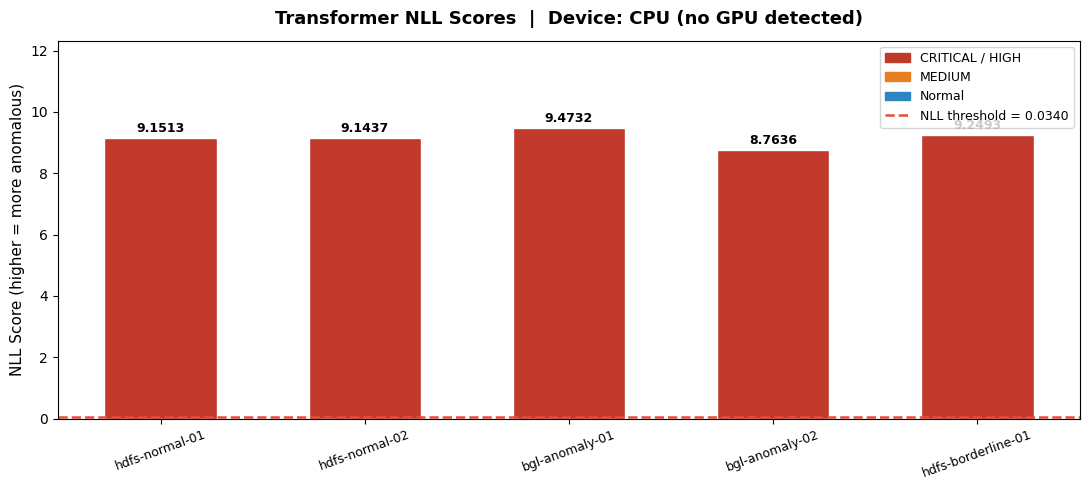

In [7]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    seq_ids = [r["sequence_id"] for r in t_results]
    scores  = [r["score"]       for r in t_results]
    sevs    = [r["severity"]    for r in t_results]

    def _bar_color(sev: str) -> str:
        if sev in ("CRITICAL", "HIGH"): return "#C0392B"
        if sev == "MEDIUM":             return "#E67E22"
        return "#2E86C1"

    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(seq_ids, scores, color=[_bar_color(s) for s in sevs],
                  edgecolor="white", width=0.55)

    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width() / 2, score + max(scores) * 0.01,
                f"{score:.4f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

    ax.axhline(_threshold_transformer, color="#E74C3C", linestyle="--",
               linewidth=1.8, label=f"NLL threshold = {_threshold_transformer:.4f}")

    legend_patches = [
        mpatches.Patch(color="#C0392B", label="CRITICAL / HIGH"),
        mpatches.Patch(color="#E67E22", label="MEDIUM"),
        mpatches.Patch(color="#2E86C1", label="Normal"),
    ]
    ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0],
              loc="upper right", fontsize=9)

    ax.set_title(f"Transformer NLL Scores  |  Device: {device_label}",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_ylabel("NLL Score (higher = more anomalous)", fontsize=11)
    ax.set_ylim(0, max(scores) * 1.30 + 0.01)
    ax.tick_params(axis="x", rotation=20, labelsize=9)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("matplotlib not available — skipping chart.")
    for r in t_results:
        print(f"  {r['sequence_id']:<28} score={r['score']:.4f}  "
              f"detected={'ANOMALY' if r['is_anomaly'] else 'NORMAL'}  "
              f"severity={r['severity']}")

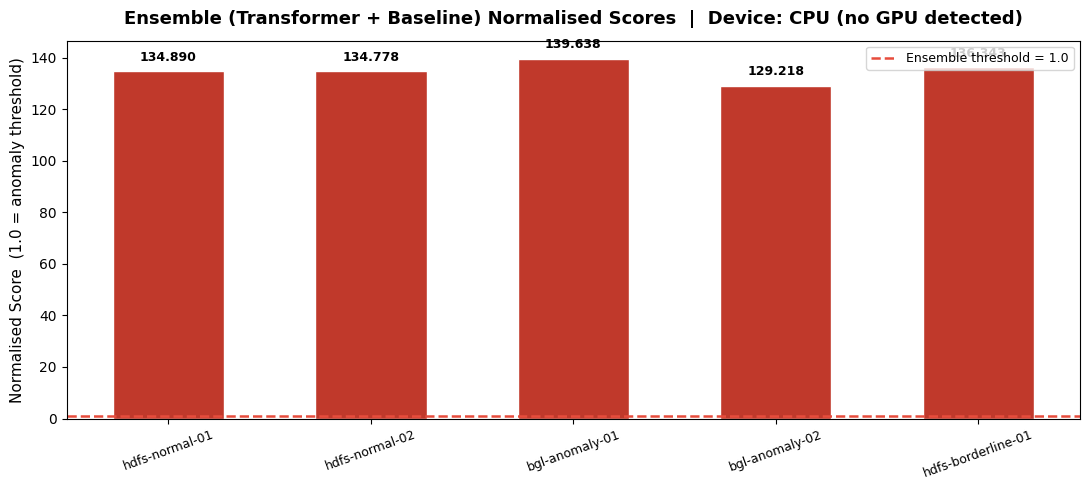

In [8]:
# Ensemble chart — only when baseline extractor was successfully fitted
if _b_scores is not None and _transformer_loaded:
    try:
        import matplotlib.pyplot as plt

        thr_b = max(_threshold_baseline,    1e-9)
        thr_t = max(_threshold_transformer, 1e-9)

        # Same normalisation formula as src/runtime/inference_engine.py
        ens_scores = [
            (float(b_s) / thr_b + float(t_s) / thr_t) / 2.0
            for b_s, t_s in zip(_b_scores, transformer_scores)
        ]
        ens_colors = ["#C0392B" if s >= 1.0 else "#2E86C1" for s in ens_scores]

        fig, ax = plt.subplots(figsize=(11, 5))
        bars = ax.bar(seq_ids, ens_scores, color=ens_colors,
                      edgecolor="white", width=0.55)

        for bar, score in zip(bars, ens_scores):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    score + max(ens_scores) * 0.02,
                    f"{score:.3f}", ha="center", va="bottom",
                    fontsize=9, fontweight="bold")

        ax.axhline(1.0, color="#E74C3C", linestyle="--",
                   linewidth=1.8, label="Ensemble threshold = 1.0")
        ax.legend(fontsize=9, loc="upper right")
        ax.set_title(
            f"Ensemble (Transformer + Baseline) Normalised Scores  |  Device: {device_label}",
            fontsize=13, fontweight="bold", pad=12)
        ax.set_ylabel("Normalised Score  (1.0 = anomaly threshold)", fontsize=11)
        ax.tick_params(axis="x", rotation=20, labelsize=9)
        plt.tight_layout()
        plt.show()

    except ImportError:
        pass
else:
    print("Ensemble chart skipped (baseline not available in this run).")

---

## 8 — Summary

This notebook demonstrated the **GPU-aware inference layer** of the Predictive Log Anomaly Engine using the real production classes from `src/`.

### What was shown

| Step | Class used | Key point |
|---|---|---|
| Device detection | `torch.cuda.is_available()` | Transparent GPU/CPU switch |
| Transformer load | `NextTokenTransformerModel.load()` | `map_location=device` + `.to(device)` |
| Transformer score | `AnomalyScorer.score()` | All tensors on same device, no extra code |
| Baseline load | `BaselineAnomalyModel.load()` | CPU-only sklearn estimator |
| Feature extraction | `BaselineFeatureExtractor` | Re-fitted on training split = same column order |
| Severity classification | `AlertPolicy.classify_severity()` | Score-to-threshold ratio |
| Ensemble | `(b_norm + t_norm) / 2.0` | Same formula as `InferenceEngine` |

### To run the full pipeline

```bash
# With Docker (recommended)
docker compose up

# Without Docker
python -m uvicorn src.api.app:create_app --factory --port 8000

# Quick smoke test
python scripts/demo_run.py
```

In [9]:
anomaly_count = sum(1 for r in t_results if r["is_anomaly"])
tp = sum(1 for r in t_results if r["is_anomaly"] and r["true_label"] == 1)
tn = sum(1 for r in t_results if not r["is_anomaly"] and r["true_label"] == 0)

print("=" * 58)
print("  Demo Summary")
print("=" * 58)
print(f"  Device                 : {device_label}")
print(f"  Transformer            : {'pretrained' if _transformer_loaded else 'untrained fallback'}")
print(f"  Baseline               : {'pretrained' if _baseline_loaded else 'not available'}")
print(f"  Baseline extractor     : {'fitted on training split' if _baseline_extractor else 'not available'}")
print(f"  Sequences scored       : {len(SAMPLE_SEQUENCES)}")
print(f"  Anomalies detected     : {anomaly_count}/{len(SAMPLE_SEQUENCES)} (transformer NLL)")
print(f"  True positives         : {tp}")
print(f"  True negatives         : {tn}")
print("=" * 58)

  Demo Summary
  Device                 : CPU (no GPU detected)
  Transformer            : pretrained
  Baseline               : pretrained
  Baseline extractor     : fitted on training split
  Sequences scored       : 5
  Anomalies detected     : 5/5 (transformer NLL)
  True positives         : 2
  True negatives         : 0
